<div style="display: flex; background-color: #5B6C9F;" >
<h1 style="margin: auto; padding: 30px; color: white; ">Détectez des faux billets - Notebook 1 - Analyse et modélisation </h1>
</div>

<div style="background-color: #C97B63;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid #C97B63;" >
<h3 style="margin: auto; padding: 20px; color: #5B6C9F; ">1.1 - Importation des librairies</h3>
</div>

In [2]:
# Importation des librairies
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

<div style="border: 1px solid #C97B63;" >
<h3 style="margin: auto; padding: 20px; color: #5B6C9F; ">1.2 - Importation du fichier</h3>
</div>

In [3]:
# Chargement du fichier
df_billets = pd.read_csv("billets.csv", sep=";")

<div style="background-color: #C97B63;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Etape 2 - Analyse exploratoire du fichier</h2>
</div>

<div style="border: 1px solid #C97B63;" >
<h3 style="margin: auto; padding: 20px; color: #5B6C9F; ">2.1 - Exploration du fichier</h3>
</div>

In [4]:
# Dimension du dataset
df_billets.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


La variable margin_low a 37 valeurs manquantes, toutes les autres sont complètes. La taille du dataset est de 1500 x 7

In [5]:
# Affichage des 5 premières lignes
df_billets.head(5)

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [6]:
# Statistiques descriptives des variables de taille
df_billets.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


Les billets sont relativement homogènes avec des écarts-types très faibles (margin_up: 0,23(min), lenght: 0,82(max)). Pas de valeurs aberrantes à premières vue (à confirmer avec boxplots). On observe néanmoins des différences conséquentes entre les différents écarts-types et les moyennes de chaque variables justifiant ainsi le recours une standardisation (Standardscaller) afin que chaque variables contribuent équitablement notamment pour l'utilisation de modèles comme le K-means ou la régressions logistique

In [7]:
# Variables de taille
taille = [
    "diagonal",
    "height_left",
    "height_right",
    "margin_low",
    "margin_up",
    "length",
]

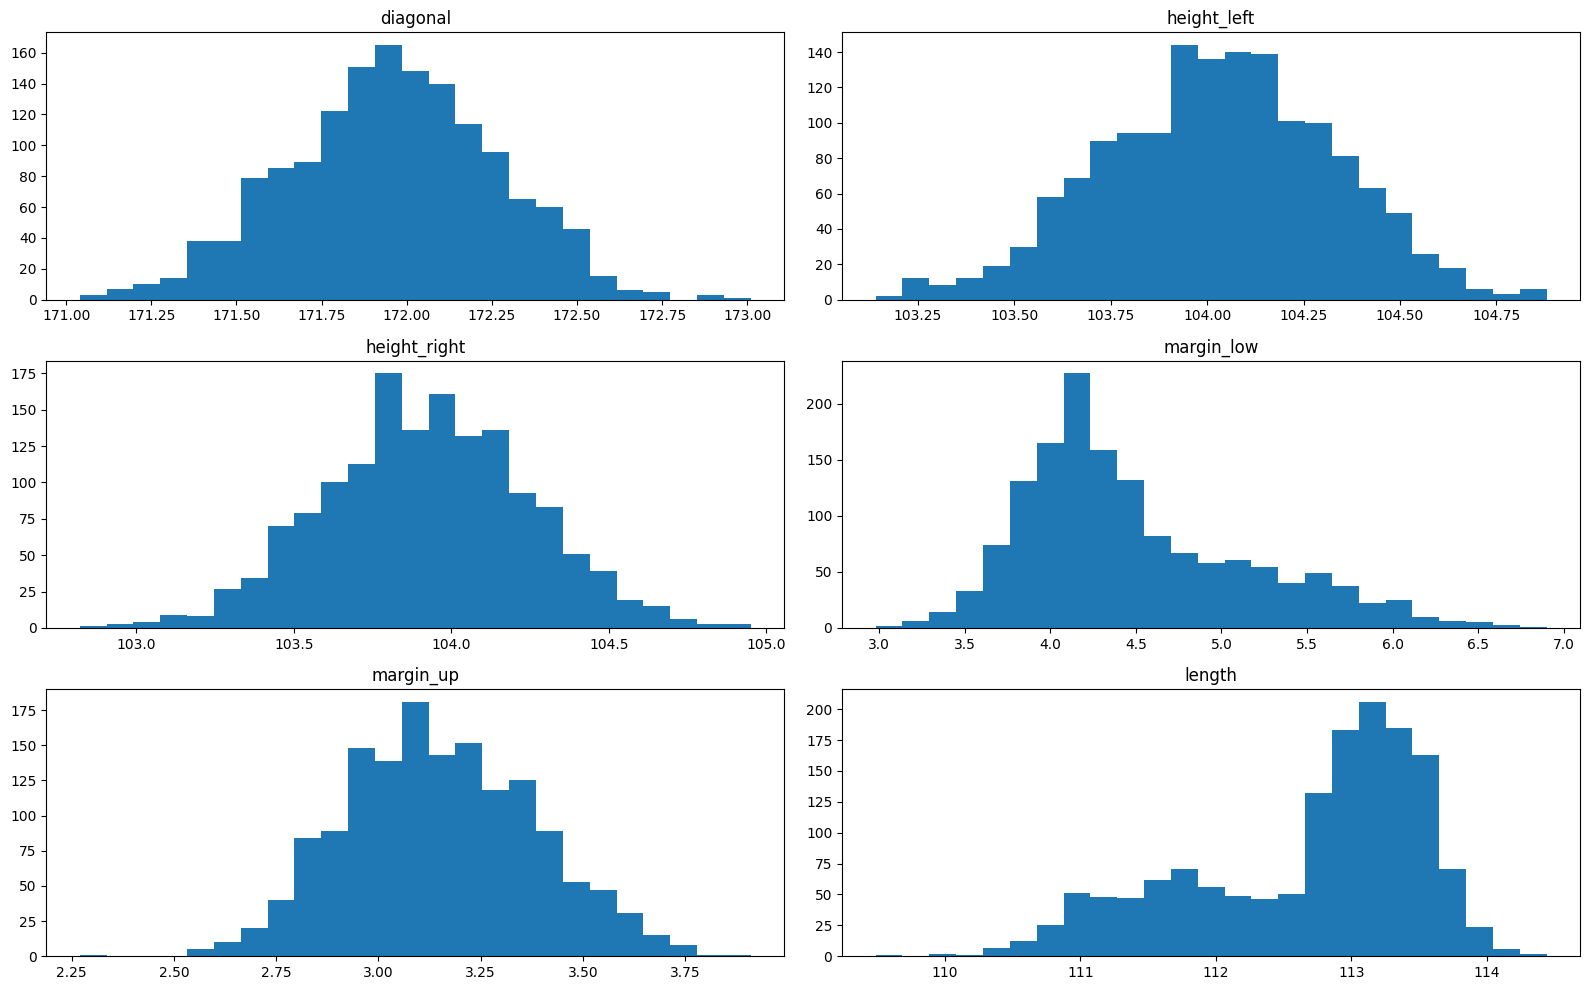

In [8]:
# Visualisation de la distribution des variables
df_billets[taille].hist(bins=25, figsize=(16, 10), grid=False)
plt.tight_layout()
plt.show()

 - La plupart des variables (diagonal, height_left, height_right, margin_up) ont une distribution unimodale et globalement symétrique supposant le suivis d'une lois normale. Les vrais et faux semble s'y chevaucher sans distinction claire. Ces variables ne semblent pas pouvoir expliquer la séparation entre un vrai et un faux billet.
 - En revanche, la variable margin_low bien qu'elle soit unimodale est asymétrique à droite suggérant deux groupes distincs, possiblement les vrais et les faux. La variable lenght quant à elle est bimodale suggérant un fort pouvoir discriminant avec deux populations qui ne se mélangent pas. 
 - Ces observations et hypothèses visuelles motive donc une analyse de corrélation.

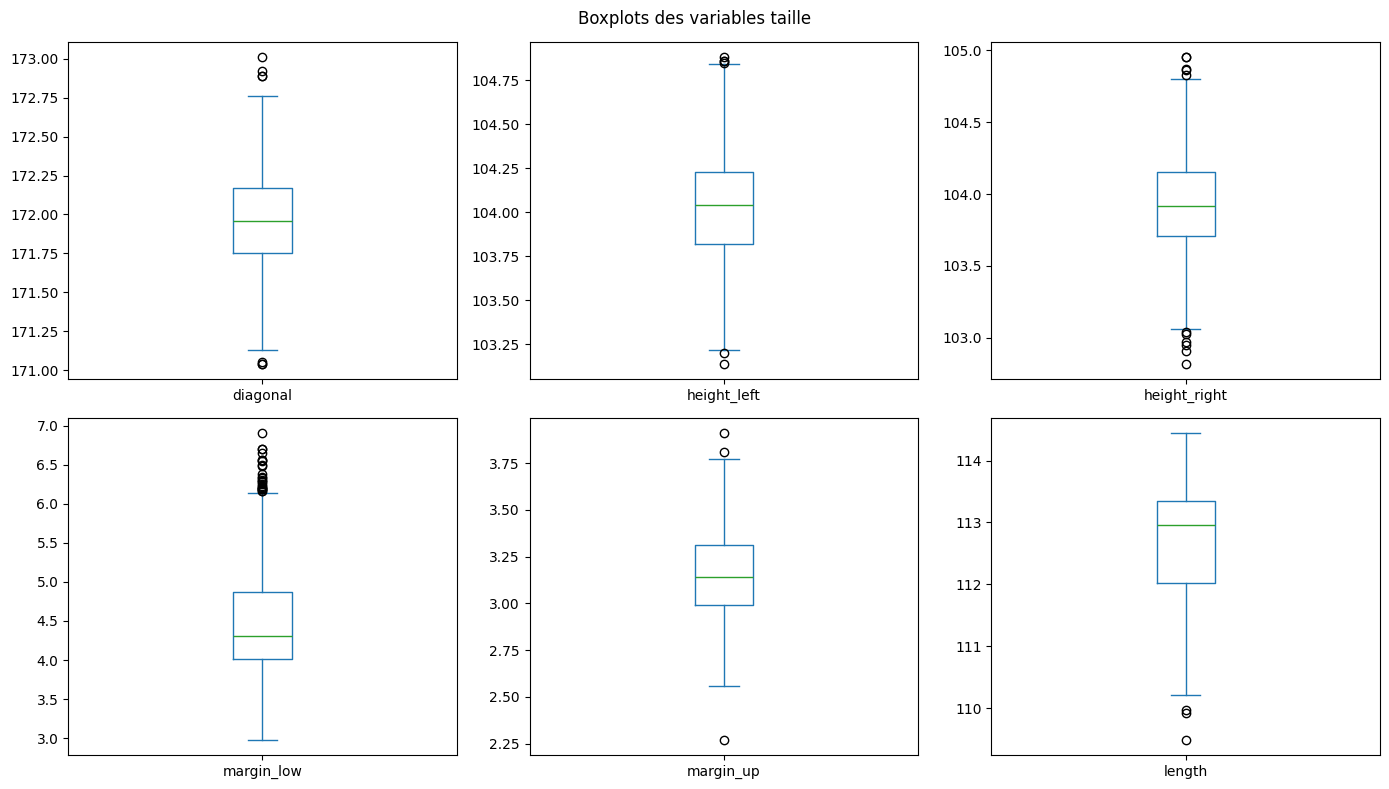

In [9]:
# Boxplots des variables de taille
df_billets[taille].plot(kind="box", subplots=True, layout=(2, 3), figsize=(14, 8))
plt.suptitle("Boxplots des variables taille")
plt.tight_layout()
plt.show()

 - Des valeurs aberrantes mais pas de valeurs négatives
  - Plusieurs points dépassent les moustaches particulièrement sur margin_low ce qui est cohérent avec l'asymétrie vue sur son histogramme 
  Dans notre cas, les points extrêmes ne sont pas des erreurs mais correspondent à des dimensions atypiques et très certainement des faux. Toutes les valeurs sont donc conservés car les outliers sont le carburant de nos futurs algorithmes de prédiction. Les supprimer retirerait du signal utile pour distinguer les vrais des faux.

<div style="border: 1px solid #C97B63;" >
<h3 style="margin: auto; padding: 20px; color: #5B6C9F; ">2.2 - Analyse des corrélations entre variables et avec la cible (is_genuine) </h3>
</div>

In [10]:
# Encodage de la cible en numérique
df_billets["cible"] = df_billets["is_genuine"].astype(int)

In [11]:
# Variables de taille + cible
taille_cible = [
    "diagonal",
    "height_left",
    "height_right",
    "margin_low",
    "margin_up",
    "length",
    "cible",
]

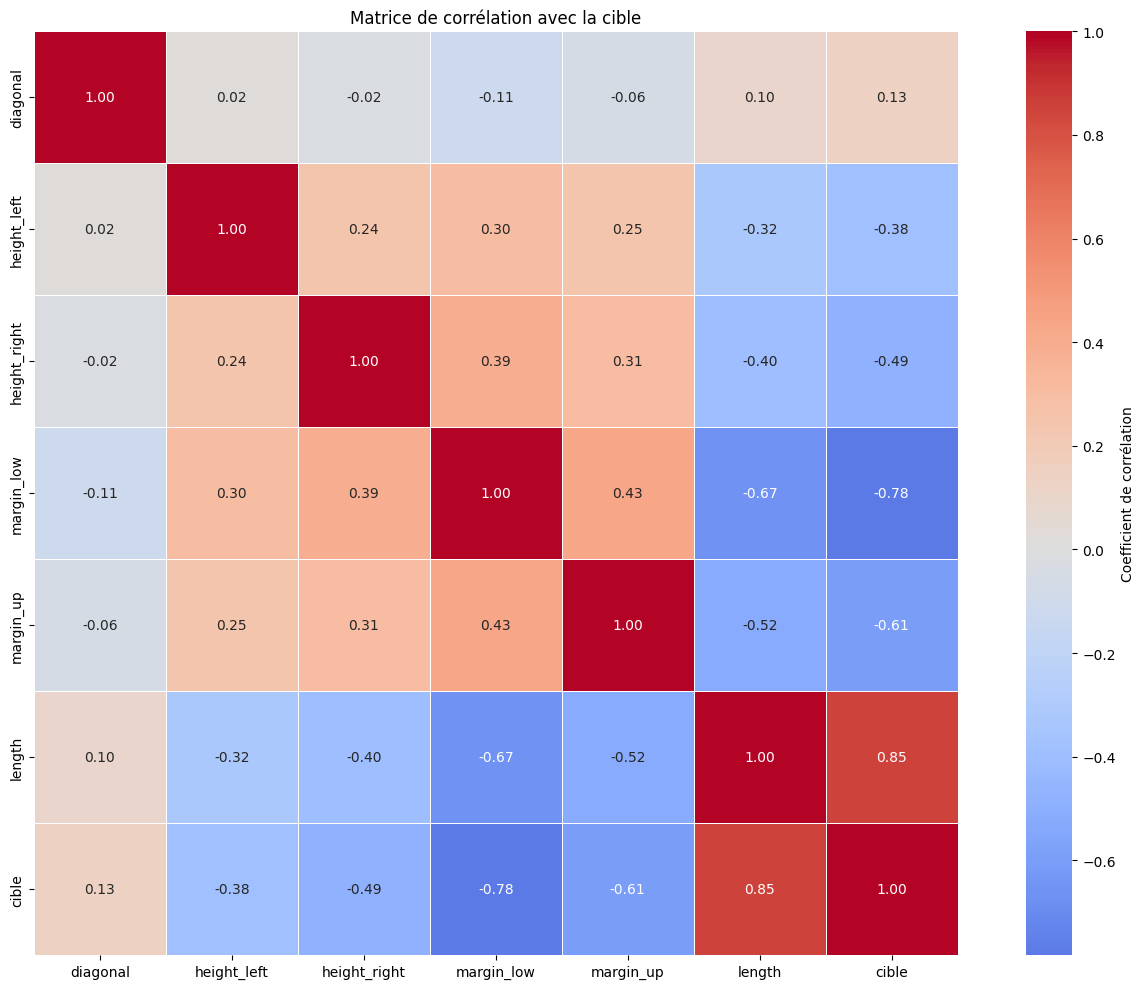

In [12]:
# Heat map de corrélations avec la cible
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_billets[taille_cible].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Coefficient de corrélation"},
)
plt.title("Matrice de corrélation avec la cible")
plt.tight_layout()
plt.show()

1- Corrélation entre variables:
 - Aucune redondance forte n'apparaît sur la matrice de corrélation nous permettant de garder toutes les variables.
  - diagonal est la variable la plus indépendante du dataset avec aucune corrélation avec les autres variables.
  - margin_low et length apparaissent comme étant fortement corrélées négativement    (-0,67), c'est d'ailleurs la corrélation la plus forte. Quand l'une augmente, l'autre diminue. Cette corrélation nous permettra donc d'utiliser la régression linéaire afin d'imputer les valeurs manquantes de margin_low. 

2- Corrélations avec la cible:
- length (0,85) et margin_low (-0,78) sont de loin les plus discriminantes, suivis de margin_up (-0,61), height_right (-0,49) et height_left (-0,38). diagonal est complètement indépendantes et quasi inutile (0,13)
- le signe donne la direction: length est positive donc les vrais sont plus long tandis que pour margin_low et margin_up sont négatives donc les vrais ont des plus petites valeurs.
- Cette matrice confirme nos hypothèse émises lors de l'étude des distributions: length et margin_low sont les plus discriminantes et margin_up sépare également les vrais des faux ce qui ne se laissait pas deviner sur les histogrammes.

<div style="border: 1px solid #C97B63;" >
<h3 style="margin: auto; padding: 20px; color: #5B6C9F; ">2.3 - Répartition des vrais / faux billets</h3>
</div>

In [13]:
# Comptage des vrais / faux billets
print(df_billets["is_genuine"].value_counts())

is_genuine
True     1000
False     500
Name: count, dtype: int64


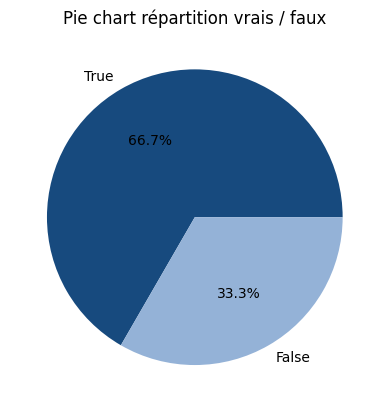

In [14]:
# Répartition des vrais / faux billets
df_billets["is_genuine"].value_counts().plot(
    kind="pie", colors=["#174A7E", "#94B2D7"], autopct="%1.1f%%"
)
plt.title("Pie chart répartition vrais / faux")
plt.show()

1500 billets sont présents dans notre dataset, 1000 sont vrais et 500 sont faux donnant ainsi une répartition de 1/3 des billets étant faux et 2/3 étant vrais

<div style="background-color: #C97B63;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Etape 3 - Préparation des données</h2>
</div>

<div style="border: 1px solid #C97B63;" >
<h3 style="margin: auto; padding: 20px; color: #5B6C9F; ">3.1 - Imputation des valeurs manquantes</h3>
</div>

In [15]:
# Importation de la régresion linéaire
from sklearn.linear_model import LinearRegression

In [16]:
# Variables pour prédire margin_low
predicteurs = ["diagonal", "height_left", "height_right", "margin_up", "length"]

In [17]:
# Séparation des billets complets de ceux à compléter
connu = df_billets[df_billets["margin_low"].notna()]
manquant = df_billets[df_billets["margin_low"].isna()]

In [18]:
# Entrainement de la régression linéaire
reg_imput = LinearRegression()
reg_imput.fit(connu[predicteurs], connu["margin_low"])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
# Prédiction de margin_low là ou la valeur est manquante
valeurs_predites = reg_imput.predict(manquant[predicteurs])

In [20]:
# Ajout des valeurs prédites
df_billets.loc[df_billets["margin_low"].isna(), "margin_low"] = valeurs_predites

In [21]:
# Vérification de l'imputation
print("Valeurs manquantes restantes:", df_billets["margin_low"].isna().sum())

Valeurs manquantes restantes: 0


<div style="border: 1px solid #C97B63;" >
<h3 style="margin: auto; padding: 20px; color: #5B6C9F; ">3.2 - Séparation X / y</h3>
</div>

In [23]:
X = df_billets[taille]
y = df_billets["cible"]

<div style="border: 1px solid #C97B63;" >
<h3 style="margin: auto; padding: 20px; color: #5B6C9F; ">3.3 - Découpage train / test</h3>
</div>

In [24]:
# Importation du train / test
from sklearn.model_selection import train_test_split

In [25]:
# Découpage en 80(train)/ 20(test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [26]:
# Vérification
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (1200, 6) | Test: (300, 6)


La séparation de nos variables explicatives (X) et notre cible (y) a été faite avec succès ainsi que le découpage de notre dataset en 2, une partie d'entrainement avec 1200 billets pour 6 variables et une partie test avec 300 billets pour 6 variables.
La fonction stratify=y nous permets de respecter rigoureusement la proportion initiale de vrais et de faux billets de notre dataset.

<div style="border: 1px solid #C97B63;" >
<h3 style="margin: auto; padding: 20px; color: #5B6C9F; ">3.4 - Standardisation </h3>
</div>

In [27]:
# Importation du standardscaller
from sklearn.preprocessing import StandardScaler

In [28]:
# Centrage et réduction
scaler = StandardScaler()

In [29]:
# Entrainement et transformation du train
x_train_scaled = scaler.fit_transform(X_train)

In [30]:
# Recréation du dataframe train
x_train_scaled = pd.DataFrame(
    x_train_scaled, columns=X_train.columns, index=X_train.index
)

In [31]:
# Affichage des 5 premières lignes du dataframe train centré et réduits
x_train_scaled.head()

,diagonal,height_left,height_right,margin_low,margin_up,length
122,-0.498491,-2.706699,0.002898,-0.765730,-0.397979,0.748396
875,-0.065093,0.194914,-1.984348,-0.781060,-0.094757,0.989435
941,0.568335,-2.273124,0.779166,-0.397813,0.511688,0.449967
494,0.401643,0.528433,0.344456,-0.581772,-0.701202,0.955000
186,0.835041,-1.839550,0.375507,-0.137206,-0.657884,0.553270


In [32]:
# Vérification du scaling avec la moyenne et l'écart-type
x_train_scaled.describe().round(2).loc[["mean", "std"]]

,diagonal,height_left,height_right,margin_low,margin_up,length
mean,0.0,-0.0,0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0


In [33]:
# Transformation du test
x_test_scaled = scaler.transform(X_test)

In [34]:
# Recréation du dataframe test
x_test_scaled = pd.DataFrame(x_test_scaled, columns=X_test.columns, index=X_test.index)

Le dataset test est seulement transformé mais pas entraîné afin de ne pas fausser l'évaluation du modèle en lui donnant des informations sur les données qu'il est censé découvrir

In [35]:
x_test_scaled.describe().round(2).loc[["mean", "std"]]

,diagonal,height_left,height_right,margin_low,margin_up,length
mean,-0.02,-0.03,0.02,-0.05,-0.01,0.06
std,1.08,0.99,1.05,1.05,1.02,1.01


 - L'ensemble des données est désormais prêt pour les algorithmes de prédictions. Les valeurs manquantes ont été imputés par régressions linéaire. 
  - Le jeux de données a été séparé en 2 parties, un jeu d'entrainement (80%) et un jeu de test (20%). 
   - Les variables explicatives du dataframe train (X_train) ont été transformés et entrainés avec pour confirmation les moyennes à 0 et les écart-types à 1.
   - Les variables explicatives du dataframe test (X_test) ont elles seulement été transformés mais pas transpformés afin de garantir l'impartialité de nos futurs modèles.

<div style="background-color: #C97B63;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Etape 4 - Algorithme de régression logistique classique</h2>
</div>

In [36]:
# Imporation de la régression logistique classique
from sklearn.linear_model import LogisticRegression

In [37]:
# Initialisation de la régression logistique
reg_log = LogisticRegression(max_iter=1000, random_state=42)

In [38]:
# Entrainement sur les datasets train
reg_log.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

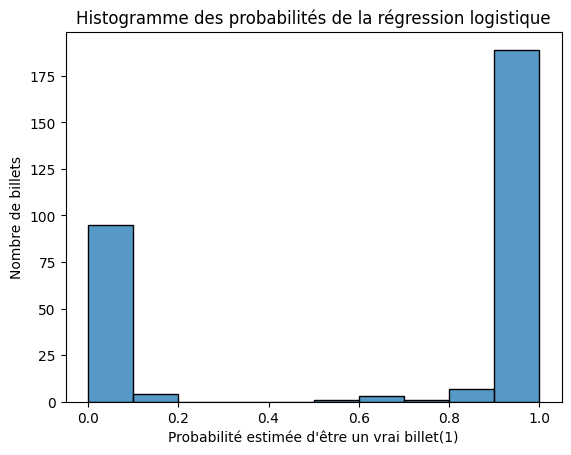

In [39]:
# Histogramme des probabilités de la régression logistique
reg_hist_proba = reg_log.predict_proba(x_test_scaled)[:, 1]
sns.histplot(reg_hist_proba)
plt.title("Histogramme des probabilités de la régression logistique")
plt.xlabel("Probabilité estimée d'être un vrai billet(1)")
plt.ylabel("Nombre de billets")
plt.show()

 - Cet histogramme représente le niveau de confiance de notre modèle pour chaque billet du jeu de test.
  - Le pic à gauche proche de 0,0 représente les billets de l'algorithme idenfitié comme étant faux et à droite proche de 1,0 les billets comme étant vrais
  - Cette distribution bimodale est idéale avec le centre du graphique qui est quasiement vide car cela prouve que notre algorithme n'hésite presque jamais pour séparer les faux des vrais billets

In [40]:
# Prédictions sur le test
y_pred_log = reg_log.predict(x_test_scaled)

In [41]:
# Score d'exactitude
from sklearn.metrics import accuracy_score

ac_reg_log = accuracy_score(y_test, y_pred_log)
ac_reg_log

0.99

Le score d'exactitude de 0,99 confirme parfaitement nos observations visuelles de l'histogramme des probabilités de la régression logistique. Notre modèle atteint une précision de 99% sur les données test et tranche ainsi fermement et avec une grande confiance entre les vrais et faux. Regardons maintenant si notre modèle est biaisé ou objectif.

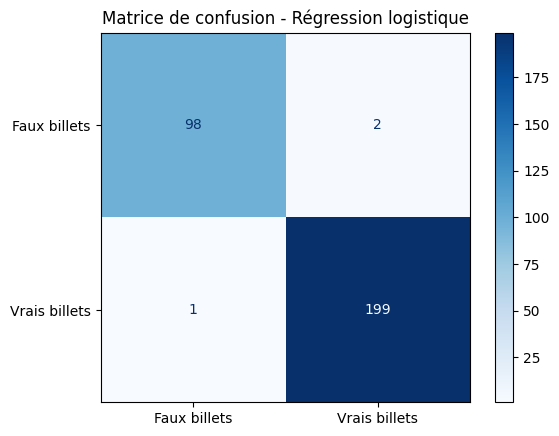

In [42]:
# Matrice de confusion
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_log, display_labels=["Faux billets", "Vrais billets"], cmap="Blues"
)
plt.title("Matrice de confusion - Régression logistique")
plt.xlabel("")
plt.ylabel("")
plt.show()

 - Vrai négatifs: 98 billets correctement identifiés comme faux
 - Vrai positifs: 198 billets correctement identifiés comme vrais
 - Faux positifs: 2 faux billets classés à tort comme vrais (contrefaçons non détectées)
 - Faux négatifs: 1 vrais billets classés à tort comme faux

 Le modèle a prédis correctement 297 billets sur 300, ce premier modèle de régression est donc extrêmement performant.
 Bien que la matrice de confusion démontre d'excellentes performances de notre modèle, nous confirmerons la robustesse de notre modèle avec le score et la courbe ROC.

Le score AUC est de: 0.9995


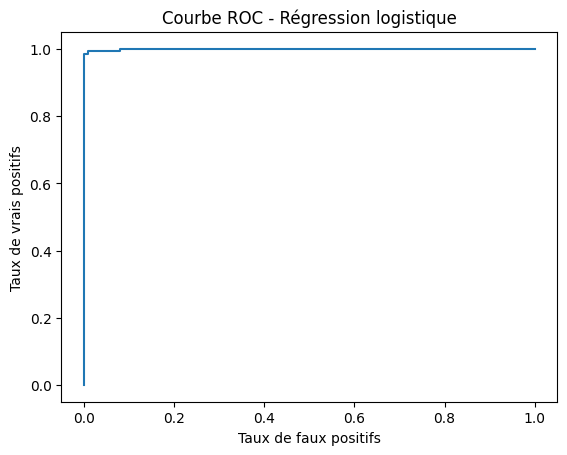

In [43]:
# Score AUC et courbe ROC
from sklearn.metrics import roc_curve, roc_auc_score

auc = roc_auc_score(y_test, reg_hist_proba)
print(f"Le score AUC est de: {auc:.4f}")
frp, tpr, thresholds = roc_curve(y_test, reg_hist_proba)
plt.plot(frp, tpr)
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - Régression logistique")
plt.show()

 - La courbe ROC et le score AUC de 0,9995 valide définitivement la qualité de ce modèle.
 - Le score AUC est extrêmement proche de 1 confirmant mathématiquement que l'algorithme possède une capacité quasi infaillible pour faire la disctinction entre les deux types de billets.
 - La courbe ROC dessine un angle droit presque parfait en direction du coin gauche droit ce qui confirme que notre modèle réussit à detecter quasiment tous les vrais billets avec un taux de vrais positifs très élevé sans presque jamais accepter de contrefaçon avec un taux de faux positifs null.

Ce graphique vient couronner les performances de notre Régression Logistique. Le modèle est exact à 99 % et il est aussi extrêmement robuste, objectif, et parfaitement prêt à être confronté à de nouvelles données.

<div style="background-color: #C97B63;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Etape 5 - Algorithme K-means</h2>
</div>

In [44]:
# Importation de K-means
from sklearn.cluster import KMeans

Contrairement à une exploration des données classiques où nous devrions chercher le nombre optimal de groupes, nous connaissons déjà notre cible à savoir 2 clusters, un vrai et un faux. Le K-means sera donc paramétré directement avec deux clusters. 

In [45]:
# K-means avec 2 clusters
kmeans2 = KMeans(n_clusters=2, random_state=42, n_init="auto")
kmeans2.fit(x_train_scaled)
clusters = kmeans2.predict(x_test_scaled)

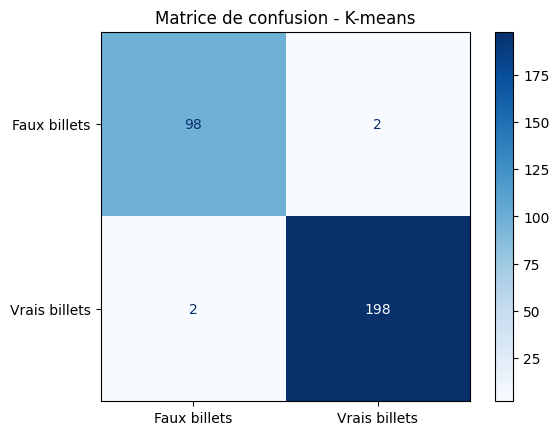

In [46]:
# Matrice de confusion
ConfusionMatrixDisplay.from_predictions(
    y_test, clusters, display_labels=["Faux billets", "Vrais billets"], cmap="Blues"
)
plt.title("Matrice de confusion - K-means")
plt.xlabel("")
plt.ylabel("")
plt.show()

 - Vrai négatifs: 98 billets correctement identifiés comme faux
 - Vrai positifs: 198 billets correctement identifiés comme vrais
 - Faux positifs: 2 faux billets classés à tort comme vrais (contrefaçons non détectées)
 - Faux négatifs: 2 vrais billets classés à tort comme faux

 Le modèle a seulement commis 4 erreurs d'affectation sur les 300 billets de test ce qui est extrêmement performant. C'est seulement un de plus que notre modèle de régression logistique.

In [47]:
# Score d'exactitude

ac_kmeans = accuracy_score(y_test, clusters)
ac_kmeans

0.9866666666666667

Le score d'exactitude est très proche de 1 (0,987) et témoigne ainsi d'une très bonne précision de l'algorithme pour décider si un billet et faux ou si il est vrai.

Le modèle du K-means s'est révélé comme étant très fiable et précis avec très peu d'erreurs de placemement et précision proche de la perfection. Même si ce dernier a démontré de très belles performances, il reste néanmoins légèrement en dessous du modèle de régression logistique qui reste pour le moment notre modèle de choix.

<div style="background-color: #C97B63;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Etape 6 - Algorithme K-Nearest Neighbors (KNN)</h2>
</div>

In [48]:
# Importation du KNN
from sklearn.neighbors import KNeighborsClassifier

Le KNN est paramétré avec K=3 car cet algorithme relève d'une classification binaire donc il faut toujours choisir un nombre impair pour prévenir la segmentation en deux groupes égaux. Dans notre cas, regarder les 3 billets les plus proches garantit ainsi qu'une majorité absolue se dégagera toujours pour prendre la décision.

In [49]:
# Initialisation du KNN avec K=3 et entrainement
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


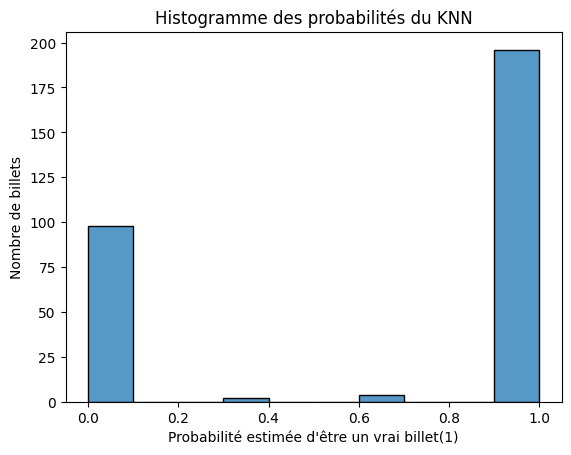

In [50]:
# Histogramme des probabilités du KNN
knn_hist_proba = knn.predict_proba(x_test_scaled)[:, 1]
sns.histplot(knn_hist_proba)
plt.title("Histogramme des probabilités du KNN")
plt.xlabel("Probabilité estimée d'être un vrai billet(1)")
plt.ylabel("Nombre de billets")
plt.show()

Contrairement à la régression logistique, le KNN à légèrement plus de difficultés pour trancher des de petits blocs proche de 0,4 et 0,6. Le modèle reste quand même très performant avec deux grandes barres aux extrémités (0,0 et 1,0).

In [51]:
# Prédiction du test
y_pred_knn = knn.predict(x_test_scaled)

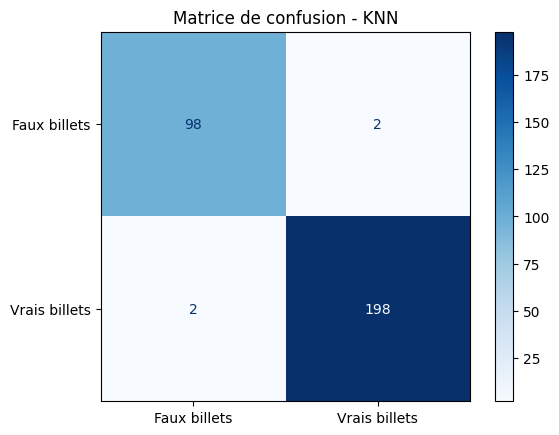

In [52]:
# Matrice de confusion
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn, display_labels=["Faux billets", "Vrais billets"], cmap="Blues"
)
plt.title("Matrice de confusion - KNN")
plt.xlabel("")
plt.ylabel("")
plt.show()

 - Vrai négatifs: 98 billets correctement identifiés comme faux
 - Vrai positifs: 198 billets correctement identifiés comme vrais
 - Faux positifs: 2 faux billets classés à tort comme vrais (contrefaçons non détectées)
 - Faux négatifs: 2 vrais billets classés à tort comme faux

 Le modèle a seulement commis 4 erreurs d'affectation sur les 300 billets ce qui est un résultat identique au modèle du K-means.

In [53]:
# Score d'exactitude
ac_knn = accuracy_score(y_test, y_pred_knn)
ac_knn

0.9866666666666667

Le score d'exactitude est également identique au précédent modèle indiquant un taux de réussite très élevé (0,987) indiquant que ce modèle est lui aussi très performant.

Le score AUC est de: 0.9972


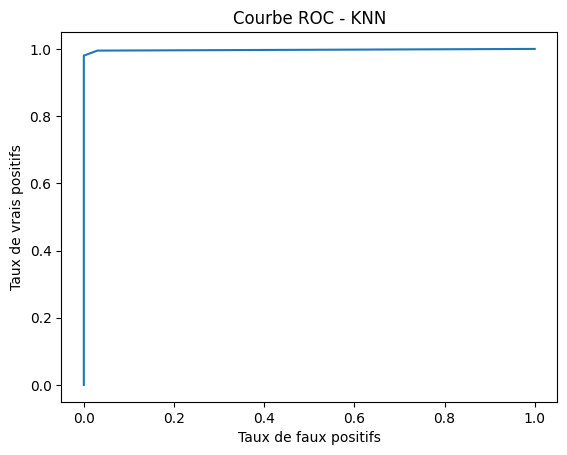

In [54]:
# Score AUC et courbe ROC
auc_knn = roc_auc_score(y_test, knn_hist_proba)
print(f"Le score AUC est de: {auc_knn:.4f}")
frp_knn, tpr_knn, thresholds_knn = roc_curve(y_test, knn_hist_proba)
plt.plot(frp_knn, tpr_knn)
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - KNN")
plt.show()

 - Pour valider la robustesse du modèle, nous avons calculé le score AUC et sa courbe ROC et tous les deux sont remarquables. 
 - Le score AUC de 0,9972 est très proche de 1 indique un modéle presque parfait mathématiquement qui fais la distinction entre un vrai et un faux billets quasiment sans erreur.
 - La courbe ROC trace un angle droit quasi parfait sur le coin gauche indiquant que notre modèle est proche d'être bullet-proof.

L'algorithme KNN s'avère comme étant extrêmement précis avec des résultats identique à ceux du K-means. Nénmoins, bien que ces derniers soient remarquable, le modèlde de régression logistique demeure toujours comme le plus performants mais de très peu.

<div style="background-color: #C97B63;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Etape 7 - Algorithme Random Forest</h2>
</div>

In [55]:
# Importation du Random Forest
from sklearn.ensemble import RandomForestClassifier

In [56]:
# Initialisation du modèle
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [57]:
# Entraînement sur les données
rf.fit(x_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

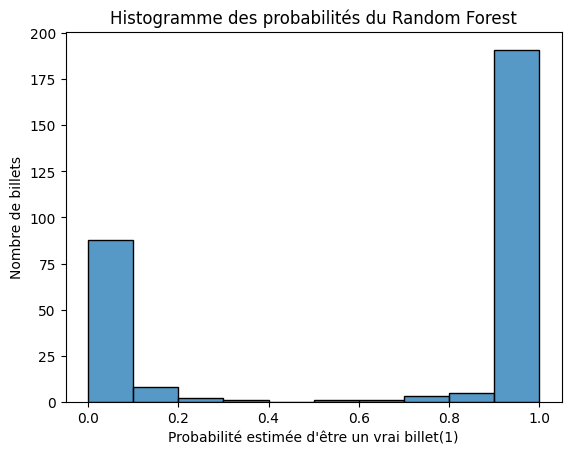

In [58]:
# Histogramme des probabilités du Random Forest
rf_hist_proba = rf.predict_proba(x_test_scaled)[:, 1]
sns.histplot(rf_hist_proba)
plt.title("Histogramme des probabilités du Random Forest")
plt.xlabel("Probabilité estimée d'être un vrai billet(1)")
plt.ylabel("Nombre de billets")
plt.show()

L'histogramme des probabilités du Random Forest indique que le modèle est extrêmement confiant dans ses choix. La grande majorité des billets sont classés aux deux extrêmes (0,0 et 1,0). Contrairement à la régression logistique qui classe de façon binaire(vrais/faux), on observe légèrement plus de petites marches entre les extrêmes qui sont dues à l'apprentissage d'ensemble composé de 100 arbres de décision.

In [59]:
# Predictions sur le jeu test
y_pred_rf = rf.predict(x_test_scaled)

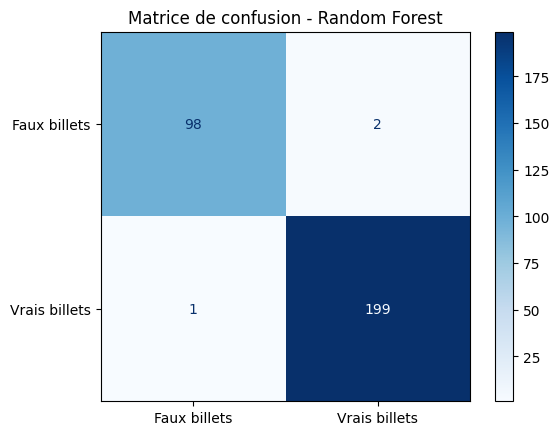

In [60]:
# Matrice de confusion
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=["Faux billets", "Vrais billets"], cmap="Blues"
)
plt.title("Matrice de confusion - Random Forest")
plt.xlabel("")
plt.ylabel("")
plt.show()

 - Vrai négatifs: 98 billets correctement identifiés comme faux
 - Vrai positifs: 198 billets correctement identifiés comme vrais
 - Faux positifs: 2 faux billets classés à tort comme vrais (contrefaçons non détectées)
 - Faux négatifs: 1 vrais billets classés à tort comme faux

 Le modèle a prédis correctement 297 billets sur 300, cette matrice de confusion est identique que celle de la régression logistique.

In [61]:
# Score d'exactitude
ac_rf = accuracy_score(y_test, y_pred_rf)
ac_rf

0.99

Le score d'exactitude de 0,99 témoigne de fiabilité quasi parfaite de ce modèle pour identifier les contrefaçons.

Le score AUC est de: 0.9994


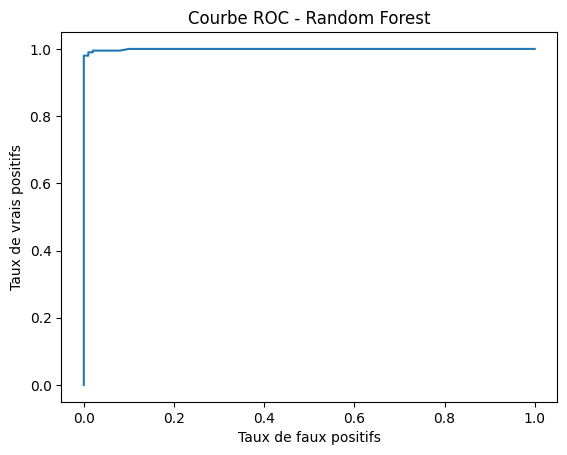

In [62]:
# Score AUC et courbe ROC
auc_rf = roc_auc_score(y_test, rf_hist_proba)
print(f"Le score AUC est de: {auc_rf:.4f}")
frp_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf_hist_proba)
plt.plot(frp_rf, tpr_rf)
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - Random Forest")
plt.show()

 - La courbe ROC dessine un angle droit presque parfait avec de très légers décrochages dans le coin gauche à l'image de nos autres modèles témoignant de la robustesse commune de nos modèles à determiner la nature d'un billet sans presque jamais déclencher de faux diagnostics. Cependant, notre modèle de régression logistique et de Random Forest étant quasiement identique en tout points (matrice de confusion, score d'exactitude et courbe ROC), notre ultime critère pour les départager est le score AUC qui est de 0,9994 pour le Random Forest et de 0,9995 pour la régression logistique.
 - Bien que le Random Forest soit réputé pour sa grande puissance, le fait que nos variables discriminantes le soit de manière simple et monotone installe une linéarité rendant la régression logistique aussi performante que le Random Forest mais plus simple.
 - Selon le principe de parcimonie (rasoir d'Ockham), le modèle de régression logistique est donc le modèle retenue.


<div style="background-color: #C97B63;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Etape 8 - Sauvegarde du meilleur modèle</h2>
</div>

In [63]:
# Importation de make_pipeline et joblib
from sklearn.pipeline import make_pipeline
import joblib

In [64]:
# Création du pipeline final à exporter avec le standardscaler et le modèle (régression logistique) et son entrainement
pipeline_final = make_pipeline(
    StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)
)
pipeline_final.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

In [65]:
# Sauvegarde du modèle
joblib.dump(pipeline_final, "modele_detection_faux_billets.joblib")

['modele_detection_faux_billets.joblib']